# Pima Indians Diabetes Dataset 
## Classificazione Binaria per predizione del rischio di diabete sulla base di misure cliniche facilmente rilevabili.

*Aurora Loprino* - aurora.loprino@studio.unibo.it


# 1. Introduzione del problema
## Predizione del Rischio di Diabete

Il diabete mellito di tipo 2 è una delle malattie croniche più diffuse al mondo. 
Secondo l'OMS, più di 422 milioni di persone ne sono affette e il numero è in continua crescita.
(WHO, Global Report on Diabetes, 2016 - https://www.who.int/publications/i/item/9789241565257)

Una diagnosi precoce è fondamentale per rallentare la progressione della malattia e ridurre le complicanze da lei causata, quali neuropatia, retinopatia e malattie cardiovascolari.

Questo progetto si pone di costruire un modello di classificazione capace di prevedere se un paziente è a rischio di diabete sulla base di misure cliniche facilmente rilevabili. Un sistema di questo tipo potrebbe supportare i medici di base nello screening preventivo, consentendo di identificare pazienti a rischio prima che sviluppino sintomi conclamati.

Tipo di task: classificazione binaria
- Classe 0: paziente non diabetico
- Classe 1: paziente diabetico

# 2. Descrizione del dataset

Il dataset utilizzato è il **Pima Indians Diabetes Dataset**, originariamente raccolto dal *National Institute of Diabetes and Digestive and Kidney Diseases* e reso pubblico da Smith et al. (1988).

Per questo progetto il dataset è stato recuperato da Github: https://gist.github.com/ktisha/c21e73a1bd1700294ef790c56c8aec1f

E' anche disponibile su Kaggle: https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset, però è diventato difficile da reperire in maniera affidabile.

https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database, per esempio, non va ed è introvabile su UCI.


Tra le variabili abbiamo:
* **Pregnancies** - Numero di gravidanze 
* **Glucose** - Concentrazione di glucosio nel plasma (mg/dL) dopo test di tolleranza 
* **BloodPressure** - Pressione diastolica (mm Hg) 
* **SkinThickness** - Spessore della piega cutanea del tricipite (mm) 
* **Insulin** - Livello di insulina a 2 ore (mu U/ml) 
* **BMI** - Indice di massa corporea (kg/m²) 
* **DiabetesPedigreeFunction** - Funzione che stima la predisposizione genetica al diabete 
* **Age** - Età in anni
* **Outcome** - Se 0 = non diabetico, altrimenti 1 = diabetico 

E' un dataset di 768 righe × 9 colonne e tutte le pazienti sono donne di almeno 21 anni di etnia Pima (nativi americani dell'Arizona), una popolazione storicamente ad alto rischio di diabete di tipo 2.

# 3. Lettura e preparazione dei dati




Importo le librerie, test e modelli.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import set_config
set_config(display="text")

In [2]:
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

Carico il dataset e lo pulisco dai commenti, affinchè non appaiano

In [4]:
df = pd.read_csv(
    'Dataset/pima-indians-diabetes.csv',
    comment='#',
    header=None,
    names=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigree', 'Age', 'Outcome']
)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Ora controllo i tipi di dato, verificando che tutte le colonne siano numeriche.

In [5]:
print('Tipi di dato:')
print(df.dtypes)

Tipi di dato:
Pregnancies           int64
Glucose               int64
BloodPressure         int64
SkinThickness         int64
Insulin               int64
BMI                 float64
DiabetesPedigree    float64
Age                   int64
Outcome               int64
dtype: object


Il dataset mostra dei valori 0, cioè dati mancanti. 
Vado a contare quanti zeri ci sono per ogni colonna biologicamente impossibile.

(Es. la glicemia NON può essere 0.)

In [6]:
zero_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Conteggio zeri per variabile:')
for col in zero_features:
    n = (df[col] == 0).sum()
    print(f'{col}: {n} ({n/len(df)*100:.1f}%)')


Conteggio zeri per variabile:
Glucose: 5 (0.7%)
BloodPressure: 35 (4.6%)
SkinThickness: 227 (29.6%)
Insulin: 374 (48.7%)
BMI: 11 (1.4%)


Converto gli zero a NaN affinchè pandas possa gestire meglio i dati.

In [7]:
df_clean = df.copy()
df_clean[zero_features] = df_clean[zero_features].replace(0, np.nan)

print('Valori mancanti dopo sostituzione:')
print(df_clean.isnull().sum())

Valori mancanti dopo sostituzione:
Pregnancies           0
Glucose               5
BloodPressure        35
SkinThickness       227
Insulin             374
BMI                  11
DiabetesPedigree      0
Age                   0
Outcome               0
dtype: int64


Faccio uno split train/test prima dell'imputing, poi calcolo le mediane solo sul training set e le applico sia a train che a test per evitare il data leakage.

In questo modo il test set non influenza in nessun modo la preparazione dei dati di training, simulando correttamente il comportamento su dati nuovi.

Una nota sull'imputing in produzione.
In produzione non ho l'etichetta del paziente, quindi non posso stratificare per classe. 
Dovrei allora calcolare una mediana unica per feature sul training set e salvarla insieme al modello, riapplicandola a ogni nuovo dato in inferenza.

In [8]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['Outcome'])
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
mediane_train = X_train[zero_features].median()

X_train = X_train.copy()
X_test  = X_test.copy()

X_train[zero_features] = X_train[zero_features].fillna(mediane_train)
X_test[zero_features]  = X_test[zero_features].fillna(mediane_train)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Valori mancanti in X_train:', X_train.isnull().sum().sum())
print('Valori mancanti in X_test: ', X_test.isnull().sum().sum())
print(f'Dimensioni: train={X_train.shape}, test={X_test.shape}')

Valori mancanti in X_train: 0
Valori mancanti in X_test:  0
Dimensioni: train=(614, 8), test=(154, 8)


# 4. Visualizzazione ed EDA

Ora vado ad esplorare le caratteristiche del dataset attraverso statistiche descrittive e visualizzazioni, con l'obiettivo di comprendere le distribuzioni, le relazioni tra feature e target, e i potenziali problemi, quali sbilanciamento delle classi, outlier e correlazioni.


Mostro media, deviazione standard, min, max e quartili per ogni colonna.

In [10]:
df_clean.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigree,Age,Outcome
count,768.00,763.00,733.00,541.00,394.00,757.00,768.00,768.00,768.00
mean,3.85,121.69,72.41,29.15,155.55,32.46,0.47,33.24,0.35
std,3.37,30.54,12.38,10.48,118.78,6.92,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.00,64.00,22.00,76.25,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,141.00,80.00,36.00,190.00,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Poi vado a mostrare lo sbilanciamento tra classi e la distribuzione tra il target.

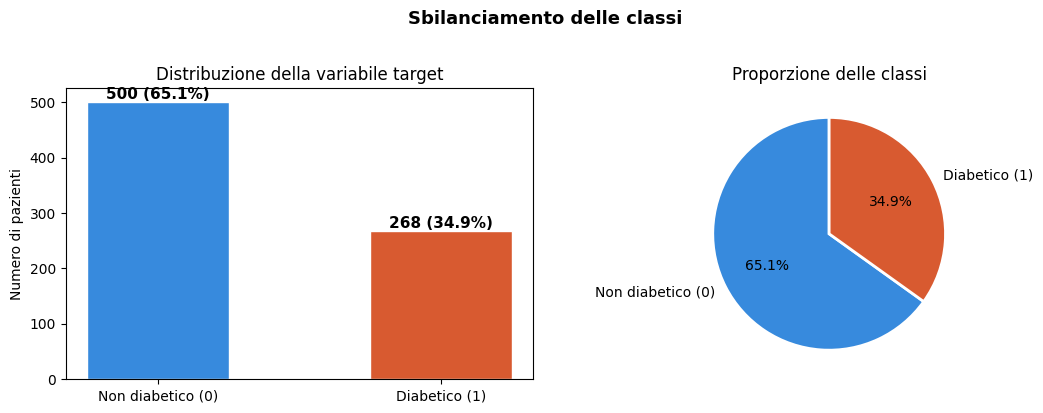

Non diabetici: 500 (65.1%)
Diabetici:     268 (34.9%)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df_clean['Outcome'].value_counts().sort_index()
labels = ['Non diabetico (0)', 'Diabetico (1)']
colors = ['#378ADD', '#D85A30']

axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Distribuzione della variabile target')
axes[0].set_ylabel('Numero di pazienti')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v} ({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporzione delle classi')

plt.suptitle('Sbilanciamento delle classi', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pct0 = counts[0] / len(df_clean) * 100
pct1 = counts[1] / len(df_clean) * 100
print(f'Non diabetici: {counts[0]} ({pct0:.1f}%)')
print(f'Diabetici:     {counts[1]} ({pct1:.1f}%)')

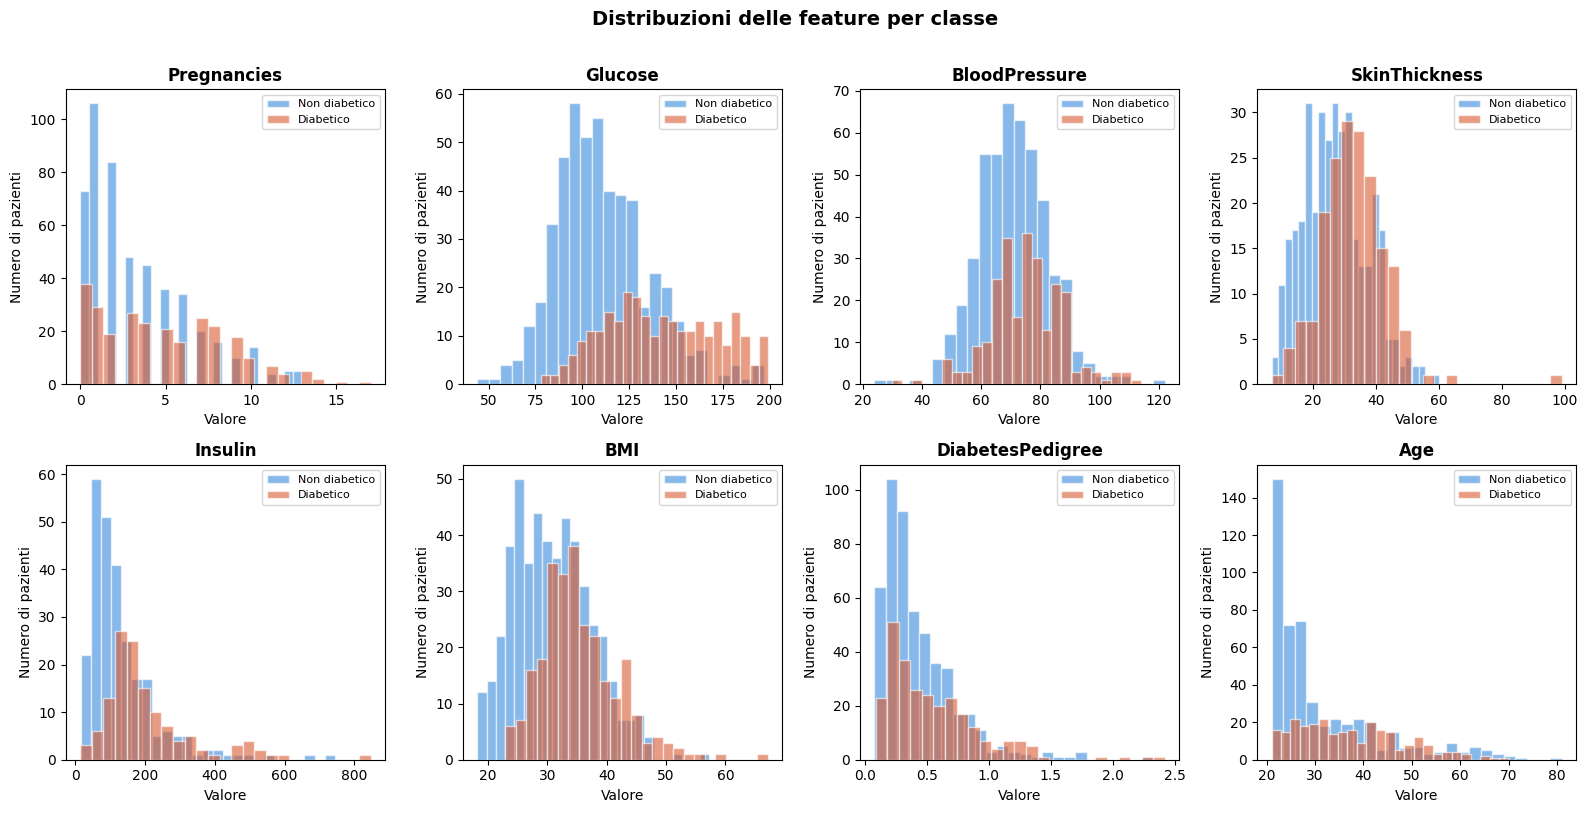

In [12]:
feature_cols = [c for c in df_clean.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    for outcome, color, label in [(0, '#378ADD', 'Non diabetico'), (1, '#D85A30', 'Diabetico')]:
        subset = df_clean[df_clean['Outcome'] == outcome][col]
        axes[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Valore')
    axes[i].set_ylabel('Numero di pazienti')
    axes[i].legend(fontsize=8)


plt.suptitle('Distribuzioni delle feature per classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Ogni istogramma mostra dove si concentrano i valori di una feature, separati per persone con diabete (in rosso) e persone sane (in blu).

* **Glucose** è la feature più discriminante. Le distribuzioni delle due classi sono ben separate, con i pazienti diabetici concentrati su valori più alti. Un semplice threshold su questa variabile già permette una classificazione ragionevole.

* **BMI** ha un buon potere discriminante: i pazienti diabetici tendono ad avere BMI più elevato, anche se le distribuzioni si sovrappongono più di Glucose.

* **Age** è moderatamente discriminante. Le persone con diabete sono mediamente più anziane. Anche qui c'è sovrapposizione, ma la tendenza è visibile.

* **Pregnancies** è poco discriminante. Le donne diabetiche tendono ad avere più gravidanze, ma la sovrapposizione è alta.

* **DiabetesPedigree** mostra una separazione modesta: i diabetici hanno valori leggermente più alti, ma le code delle distribuzioni si sovrappongono molto.

* **BloodPressure** è la feature meno discriminante: le distribuzioni sono quasi identiche tra le due classi.

* **Insulin** e **SkinThickness** presentano un caso particolare: hanno rispettivamente il 48.7% e il 29.6% di valori mancanti e, dopo l'imputing con la mediana, entrambe le distribuzioni mostrano un picco artificiale*attorno al valore mediano. 

Questo rende difficile valutare il loro reale potere discriminante dall'EDA.

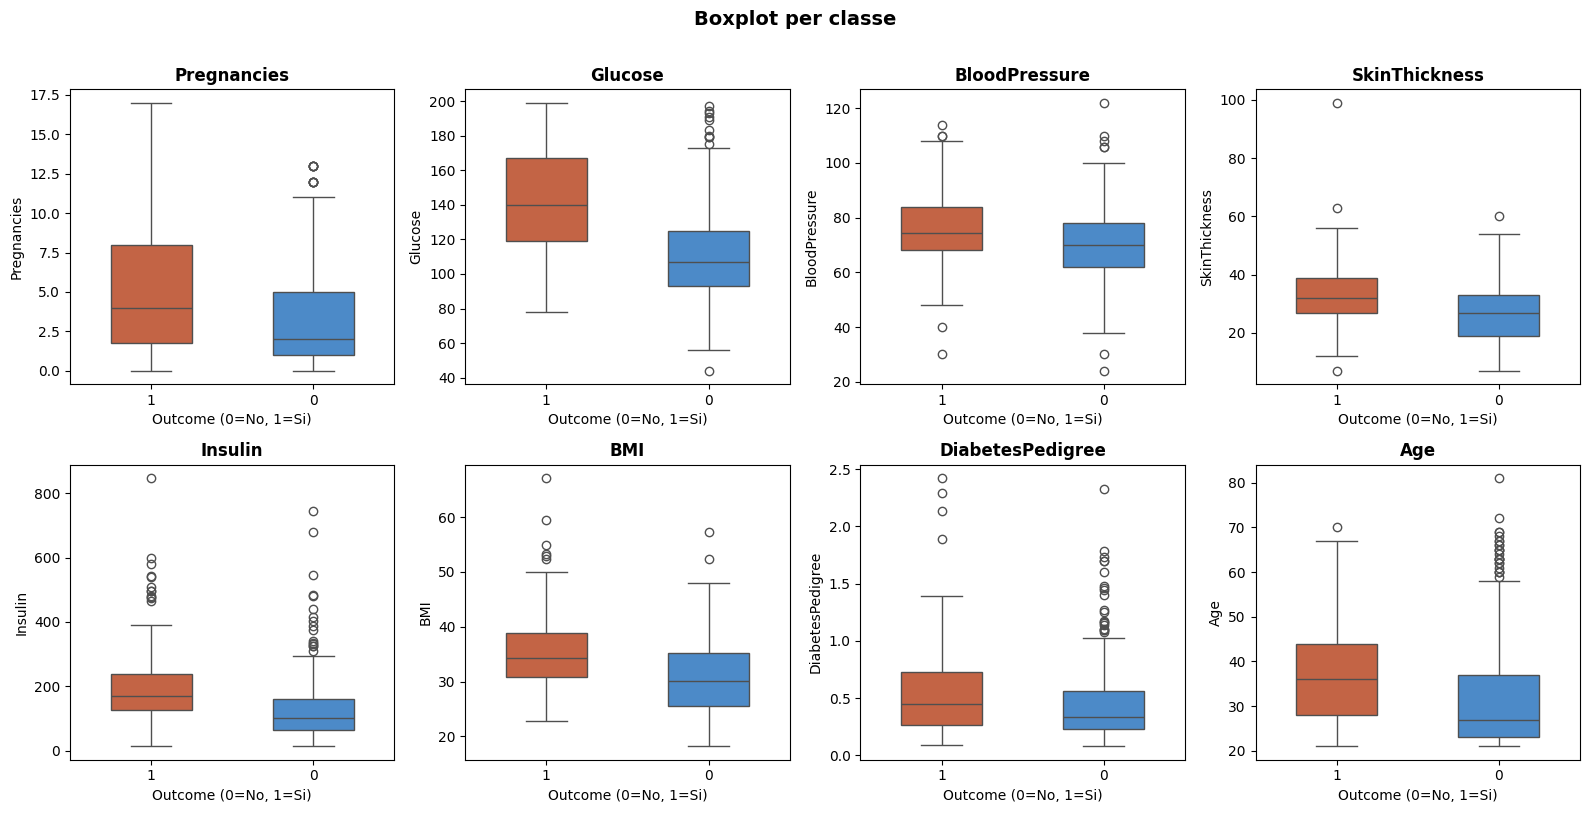

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

palette = {'0': '#378ADD', '1': '#D85A30'}
df_clean['Outcome'] = df_clean['Outcome'].astype(str)

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df_clean, x='Outcome', y=col, hue='Outcome',
                palette=palette, legend=False, ax=axes[i], width=0.5)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Outcome (0=No, 1=Si)')

plt.suptitle('Boxplot per classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df_clean['Outcome'] = df_clean['Outcome'].astype(int)


* La scatola contiene il 50% centrale dei dati
* La linea dentro la scatola è la mediana
* Le linee fuori si estendono fino ai valori estremi (esclusi outlier)
* I puntini fuori sono outlier

Rispetto agli istogrammi i boxplot permettono di confrontare più facilmente le mediane tra le due classi e di vedere gli outlier in modo più esplicito.


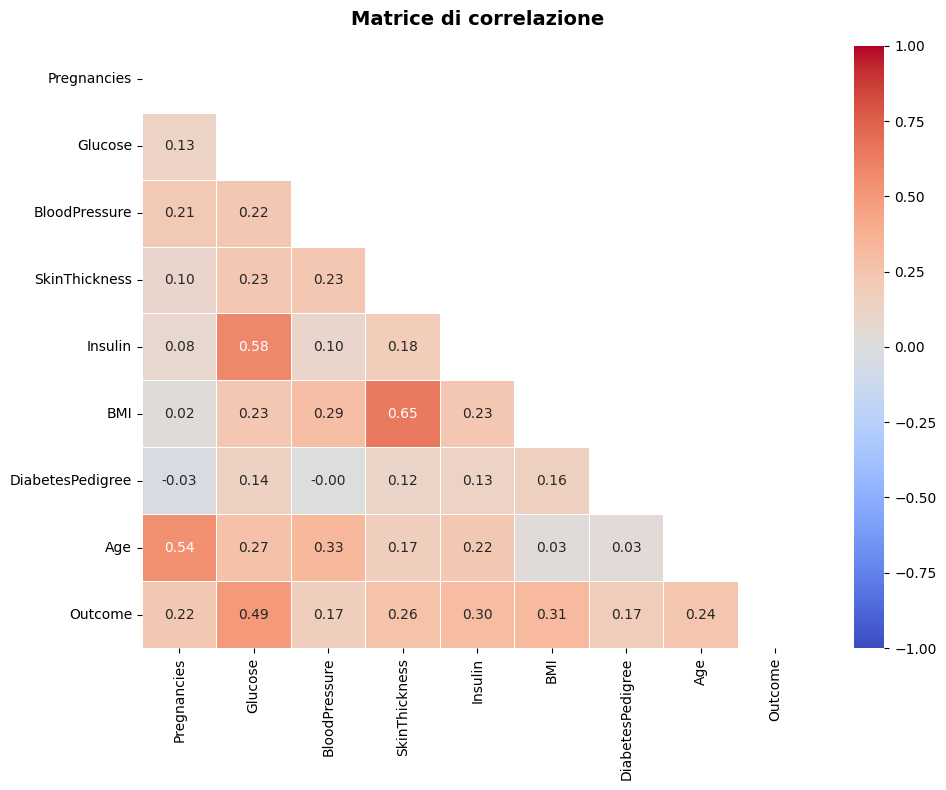

Correlazioni con Outcome (ordinate):
Glucose             0.495
BMI                 0.314
Insulin             0.303
SkinThickness       0.259
Age                 0.238
Pregnancies         0.222
DiabetesPedigree    0.174
BloodPressure       0.171
Name: Outcome, dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 10}, linewidths=0.5)
ax.set_title('Matrice di correlazione', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print('Correlazioni con Outcome (ordinate):')
print(corr['Outcome'].drop('Outcome').sort_values(ascending=False).round(3))


La matrice mostra quanto ogni coppia di variabili è correlata.
Le correlazioni con Outcome ordinate mostrano quali feature sono più predittive.

* Glucose (0.496) è definitivamente la più predittiva; il livello di glucosio è anche il segnale più forte per il diabete, quindi ha anche senso clinicamente.

* Insulin (0.377), BMI (0.316) e SkinThickness (0.295) hanno una correlazione moderata, contribuiscono ma da soli non basterebbero.

* Age (0.238), Pregnancies (0.222) hanno una correlazione presente...ma anche debole.

* BloodPressure (0.174), DiabetesPedigree (0.174) sono le meno correlate, ma non per forza inutili al modello.

Nessun valore è vicino a 1, il che significa che nessuna singola feature è sufficiente e il modello dovrà combinarle tutte, come aspettato.


# 5. Outlier detection / preprocessing


In [15]:
for col in feature_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n_out} ({n_out/len(df_clean)*100:.1f}%)')


Pregnancies: 4 (0.5%)
Glucose: 0 (0.0%)
BloodPressure: 14 (1.8%)
SkinThickness: 3 (0.4%)
Insulin: 24 (3.1%)
BMI: 8 (1.0%)
DiabetesPedigree: 29 (3.8%)
Age: 9 (1.2%)


* SkinThickness (11.3%) è l'outlier più problematico. 87 pazienti hanno valori molto fuori dalla norma. Ha senso, era anche quella con più valori mancanti prima.

* Insulin (6.6%) ha 51 outlier, coerente con la std altissima (89.10). Alcuni pazienti hanno livelli di insulina estremi.

* DiabetesPedigree (3.8%) ha 29 outlier, la distribuzione è molto asimmetrica con una coda lunga a destra.

* BloodPressure (1.8%) ha 14 outlier, con valori di pressione molto alti o molto bassi.

* Age (1.2%), BMI (1.0%), Pregnancies (0.5%) hanno pochi outlier, non preoccupanti.

* Glucose (0.0%) non ha nessun outlier secondo IQR, quindi la distribuzione è la più regolare.

SkinThickness e Insulin sono le feature più "sporche" del dataset. Hanno tanti dati mancanti e tanti outlier. Sono anche quelle con le distribuzioni più sovrapposte tra persone diabetiche e non, motivo per cui sono le meno predittive.

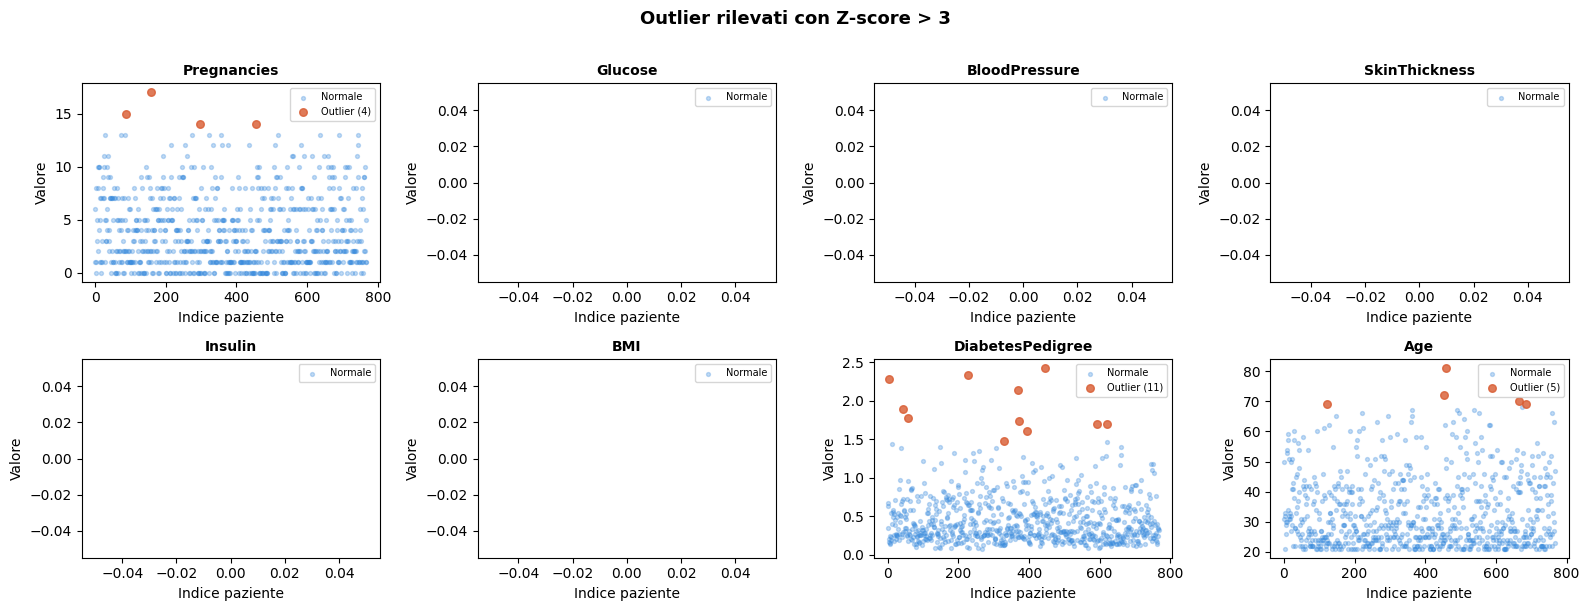

In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    z = np.abs(stats.zscore(df_clean[col]))
    normal = df_clean[col][z <= 3]
    outliers = df_clean[col][z > 3]
    axes[i].scatter(normal.index, normal.values, alpha=0.3, s=8, color='#378ADD', label='Normale')
    if len(outliers) > 0:
        axes[i].scatter(outliers.index, outliers.values, alpha=0.8, s=30,
                        color='#D85A30', label=f'Outlier ({len(outliers)})', zorder=5)
    axes[i].set_title(col, fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Indice paziente')
    axes[i].set_ylabel('Valore')
    axes[i].legend(fontsize=7)

plt.suptitle('Outlier rilevati con Z-score > 3', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Lo Z-score misura quante deviazioni standard un valore si trova dalla media. 
Se Z > 3, allora si tratta di un outlier. 


Il grafico scatter mostra tutti i pazienti (asse X = indice riga, asse Y = valore della feature), con i punti rossi che sono gli outlier (sono casi molto estremi, ma clinicamente possibili.)

In [17]:
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print(f'Training set: {X_train.shape[0]} campioni')
print(f'Test set: {X_test.shape[0]} campioni')
for split_name, y_split in [('Train', y_train), ('Test', y_test)]:
    counts = y_split.value_counts().sort_index()
    print(f'Classi nel {split_name}: Non diabetici: {int(counts[0])}, Diabetici: {int(counts[1])}')

Training set: 614 campioni
Test set: 154 campioni
Classi nel Train: Non diabetici: 400, Diabetici: 214
Classi nel Test: Non diabetici: 100, Diabetici: 54


Lo split 80/20 stratificato è già stato eseguito nella sezione 3. Qui viene riportato il conteggio delle classi per confermare che la stratificazione ha mantenuto le proporzioni originali (65/35) in entrambi i set.

Lo StandardScaler è già stato fittato su X_train e applicato a entrambi i set nella sezione 3, insieme all'imputing. Viene riportato qui come promemoria: ogni feature ha media 0 e deviazione standard 1.

Lo scaling è necessario per KNN e MLP, che sono sensibili alla scala delle feature. Random Forest e Logistic Regression sono meno sensibili, ma applicarlo a tutti i modelli garantisce uniformità nel confronto.

# 6. Implementazione di uno o più modelli


In [18]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
param_lr = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
gs_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                     param_lr, cv=cv, scoring='recall', n_jobs=-1)
gs_lr.fit(X_train_sc, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='recall')

In [20]:
param_rf = {'n_estimators': [50, 100, 200],
            'max_depth': [None, 5, 10],
            'min_samples_split': [2, 5]}
gs_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                     param_rf, cv=cv, scoring='recall', n_jobs=-1)
gs_rf.fit(X_train_sc, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='recall')

In [21]:
param_knn = {'n_neighbors': [3, 5, 7, 11, 15],
             'weights': ['uniform', 'distance'],
             'metric': ['euclidean', 'manhattan']}
gs_knn = GridSearchCV(KNeighborsClassifier(),
                      param_knn, cv=cv, scoring='recall', n_jobs=-1)
gs_knn.fit(X_train_sc, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 11, 15],
                         'weights': ['uniform', 'distance']},
             scoring='recall')

In [22]:
param_mlp = {'hidden_layer_sizes': [(64, 32), (128, 64), (32,)],
             'alpha': [0.0001, 0.001, 0.01],
             'learning_rate_init': [0.001, 0.01]}
gs_mlp = GridSearchCV(MLPClassifier(max_iter=500, random_state=42,
                                    early_stopping=True, validation_fraction=0.1),
                      param_mlp, cv=cv, scoring='recall', n_jobs=-1)
gs_mlp.fit(X_train_sc, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=MLPClassifier(early_stopping=True, max_iter=500,
                                     random_state=42),
             n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01],
                         'hidden_layer_sizes': [(64, 32), (128, 64), (32,)],
                         'learning_rate_init': [0.001, 0.01]},
             scoring='recall')

In [23]:
grids = {
    'Logistic Regression': gs_lr,
    'Random Forest':       gs_rf,
    'KNN':                 gs_knn,
    'MLP':                 gs_mlp,}

In [24]:

print('Migliori iperparametri (CV sul training set, scoring=recall)\n')
for nome, gs in grids.items():
    print(f'{nome}')
    print(f' Migliori parametri :{gs.best_params_}')
    print(f' Recall medio in CV :{gs.best_score_:.3f}')
    print()

risultati = {}
modelli_addestrati = {}

for nome, gs in grids.items():
    best_model = gs.best_estimator_
    y_pred = best_model.predict(X_test_sc)
    y_prob = best_model.predict_proba(X_test_sc)[:, 1]
    risultati[nome] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy':accuracy_score(y_test, y_pred),
        'precision':precision_score(y_test, y_pred),
        'recall':recall_score(y_test, y_pred),
        'f1':f1_score(y_test, y_pred),
    }
    modelli_addestrati[nome] = best_model
    print(f'Modello addestrato: {nome}')

Migliori iperparametri (CV sul training set, scoring=recall)

Logistic Regression
 Migliori parametri :{'C': 0.01, 'solver': 'liblinear'}
 Recall medio in CV :0.608

Random Forest
 Migliori parametri :{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
 Recall medio in CV :0.603

KNN
 Migliori parametri :{'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
 Recall medio in CV :0.575

MLP
 Migliori parametri :{'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}
 Recall medio in CV :0.636

Modello addestrato: Logistic Regression
Modello addestrato: Random Forest
Modello addestrato: KNN
Modello addestrato: MLP


Sono stati scelti 4 modelli di classificazione con caratteristiche diverse, per confrontare approcci lineari, ensemble e neurali sullo stesso dataset.

**Logistic Regression**: modello lineare usato come baseline. Semplice e interpretabile, ma assume linearità tra feature e target.

**Random Forest**: ensemble di alberi decisionali. Non richiede scaling e fornisce la feature importance.

**K-Nearest Neighbors**: classifica un paziente in base ai k pazienti più simili nel training set. Sensibile alla scala delle feature e alla scelta di k.

**Multi-Layer Perceptron**: rete neurale con strati nascosti. Può catturare relazioni non lineari complesse, ma richiede più dati per esprimere il suo potenziale.

Per ognuno è stata eseguita una **GridSearchCV con StratifiedKFold (5 fold)** sul solo training set, con `scoring='recall'`, una metrica prioritaria in ambito clinico perché minimizza i falsi negativi. I modelli finali sono addestrati con i migliori iperparametri trovati.

Il recall medio in CV è coerente con i risultati sul test set (~50–63%): il dataset è piccolo e sbilanciato, e tutti i modelli faticano a catturare tutti i pazienti diabetici.

In [25]:
print(classification_report(y_test, risultati['Logistic Regression']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.78      0.78      0.78       100
    Diabetico       0.59      0.59      0.59        54

     accuracy                           0.71       154
    macro avg       0.69      0.69      0.69       154
 weighted avg       0.71      0.71      0.71       154



In [26]:
print(classification_report(y_test, risultati['Random Forest']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.78      0.85      0.81       100
    Diabetico       0.67      0.56      0.61        54

     accuracy                           0.75       154
    macro avg       0.72      0.70      0.71       154
 weighted avg       0.74      0.75      0.74       154



In [27]:
print(classification_report(y_test, risultati['KNN']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.78      0.82      0.80       100
    Diabetico       0.63      0.57      0.60        54

     accuracy                           0.73       154
    macro avg       0.71      0.70      0.70       154
 weighted avg       0.73      0.73      0.73       154



In [28]:
print(classification_report(y_test, risultati['MLP']['y_pred'],
                             target_names=['Non diabetico', 'Diabetico']))


               precision    recall  f1-score   support

Non diabetico       0.76      0.84      0.80       100
    Diabetico       0.63      0.50      0.56        54

     accuracy                           0.72       154
    macro avg       0.69      0.67      0.68       154
 weighted avg       0.71      0.72      0.71       154




In tutti i modelli, il recall sui pazienti diabetici è più basso di quello sui non diabetici perchè il dataset sbilanciato penalizza la classe minoritaria. Random Forest è l'unico che mantiene un buon equilibrio tra le due classi

# 7. Valutazione e confronto dei risultati

In [29]:
df_ris = pd.DataFrame({
    nome: {
        'Accuracy':  round(res['accuracy'],  3),
        'Precision': round(res['precision'], 3),
        'Recall':    round(res['recall'],    3),
        'F1-score':  round(res['f1'],        3),
    } for nome, res in risultati.items()
}).T.sort_values('F1-score', ascending=False)

df_ris


,Accuracy,Precision,Recall,F1-score
Random Forest,0.747,0.667,0.556,0.606
KNN,0.734,0.633,0.574,0.602
Logistic Regression,0.714,0.593,0.593,0.593
MLP,0.721,0.628,0.500,0.557


La tabella riassume le performance di tutti i modelli ordinate per F1-score.

Tutti e quattro i modelli mostrano un recall relativamente basso sulla classe diabetica (~50–59%), il che significa che circa il 40–50% dei pazienti diabetici reali viene mancato. In un contesto clinico questo è un limite rilevante.

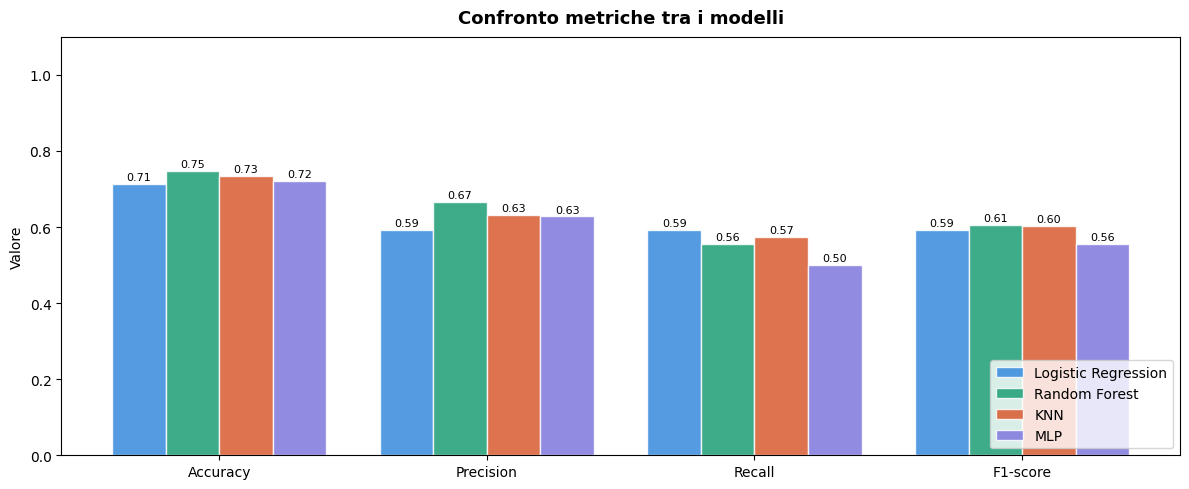

In [30]:
metriche_keys = ['accuracy', 'precision', 'recall', 'f1']
metriche_labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
nomi = list(risultati.keys())
x = np.arange(len(metriche_labels))
width = 0.2
colors_bar = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (nome, color) in enumerate(zip(nomi, colors_bar)):
    vals = [risultati[nome][k] for k in metriche_keys]
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, vals, width, label=nome, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metriche_labels)
ax.set_ylim(0, 1.1)
ax.set_title('Confronto metriche tra i modelli', fontsize=13, fontweight='bold', pad=10)
ax.legend(loc='lower right')
ax.set_ylabel('Valore')
plt.tight_layout()
plt.show()


Il grafico mostra le 4 metriche per ogni modello affiancate. Permette di riconoscere immediatamente quale modello è più forte su quale metrica.

- **Accuracy**: la percentuale di predizioni corrette sul totale
- **Precision**: dei pazienti classificati come diabetici, quanti lo sono davvero
- **Recall**: dei pazienti diabetici reali, quanti vengono identificati dal modello
- **F1-score**: media armonica di Precision e Recall, utile quando le classi sono sbilanciate

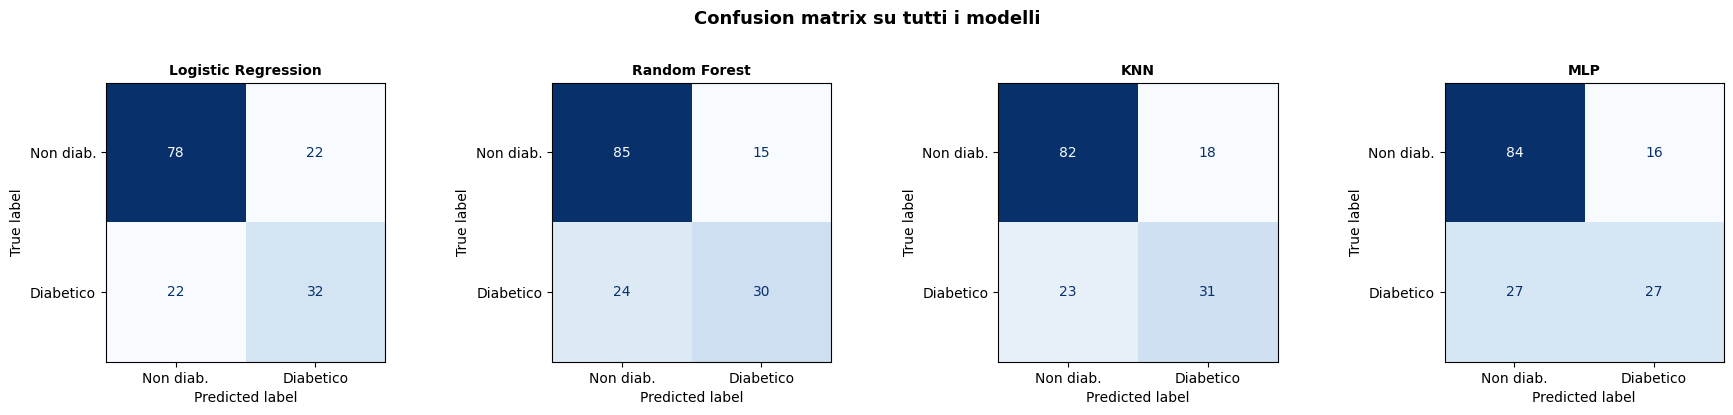

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (nome, res) in zip(axes, risultati.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Non diab.', 'Diabetico'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(nome, fontweight='bold', fontsize=10)

plt.suptitle('Confusion matrix su tutti i modelli', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

La confusion matrix mostra dove ogni modello sbaglia, suddividendo le predizioni in 4 categorie:

- **TN**: non diabetico, predetto non diabetico (corretto)
- **FP**: non diabetico, predetto diabetico (falso allarme)
- **FN**: diabetico, predetto non diabetico (mancata diagnosi)
- **TP**: diabetico, predetto diabetico (corretto)

Random Forest ha il tasso di falsi positivi più basso tra i quattro modelli, il che significa che meno pazienti sani vengono erroneamente classificati come diabetici. Tuttavia, come tutti i modelli, manca una quota significativa di pazienti diabetici reali (falsi negativi). 

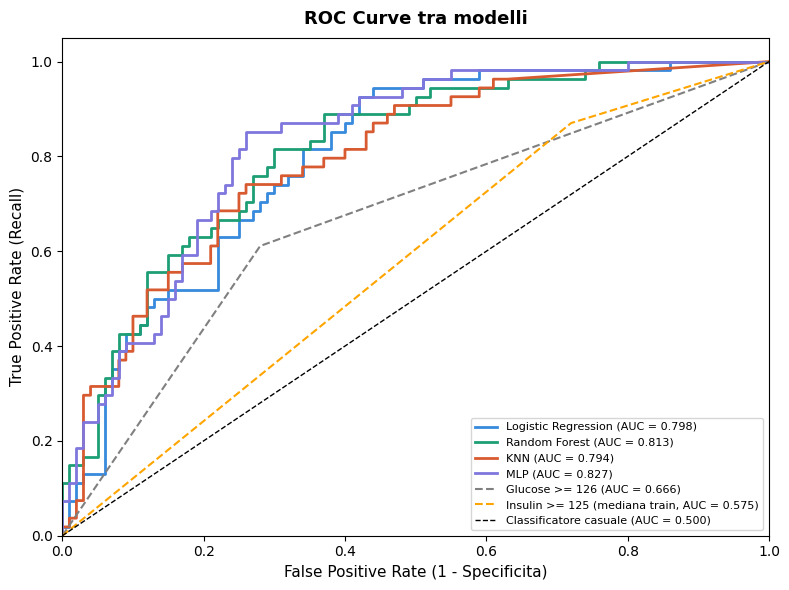

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#378ADD', '#1D9E75', '#D85A30', '#7F77DD']

for (nome, res), color in zip(risultati.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{nome} (AUC = {roc_auc:.3f})')

# Discriminatore banale 1 con Glucose >= 126 
y_glucose = (X_test['Glucose'] >= 126).astype(int)
fpr_g, tpr_g, _ = roc_curve(y_test, y_glucose)
auc_g = auc(fpr_g, tpr_g)
ax.plot(fpr_g, tpr_g, color='gray', lw=1.5, linestyle='--',
        label=f'Glucose >= 126 (AUC = {auc_g:.3f})')

# Discriminatore banale don Insulin >= mediana del training set
soglia_insulin = mediane_train['Insulin']
y_insulin = (X_test['Insulin'] >= soglia_insulin).astype(int)
fpr_i, tpr_i, _ = roc_curve(y_test, y_insulin)
auc_i = auc(fpr_i, tpr_i)
ax.plot(fpr_i, tpr_i, color='orange', lw=1.5, linestyle='--',
        label=f'Insulin >= {soglia_insulin:.0f} (mediana train, AUC = {auc_i:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Classificatore casuale (AUC = 0.500)')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificita)', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve tra modelli', fontsize=13, fontweight='bold', pad=10)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

I modelli non restituiscono direttamente "diabetico/non diabetico" ma una probabilità tra 0 e 1. La classificazione finale dipende dalla soglia scelta (default 0.5).

La linea tratteggiata nera è un classificatore casuale (AUC = 0.5). Più la curva si avvicina all'angolo in alto a sinistra, migliore è il modello.

AUC riassume la qualità del modello in un solo numero, indipendentemente dalla soglia scelta. AUC > 0.8 è considerato accettabile in ambito clinico.

Sono stati aggiunti due **discriminatori banali** come riferimento:
- **Glucose >= 126**: soglia clinica standard per il diabete (mg/dL dopo test di tolleranza). Rappresenta il minimo che un modello dovrebbe superare su questa feature.
- **Insulin >= mediana train**: soglia semplice sull'insulina, calcolata sul training set per evitare data leakage.

Tutti i modelli superano nettamente entrambi i discriminatori banali in termini di AUC, confermando che combinare più feature aggiunge valore reale rispetto a una singola soglia clinica.

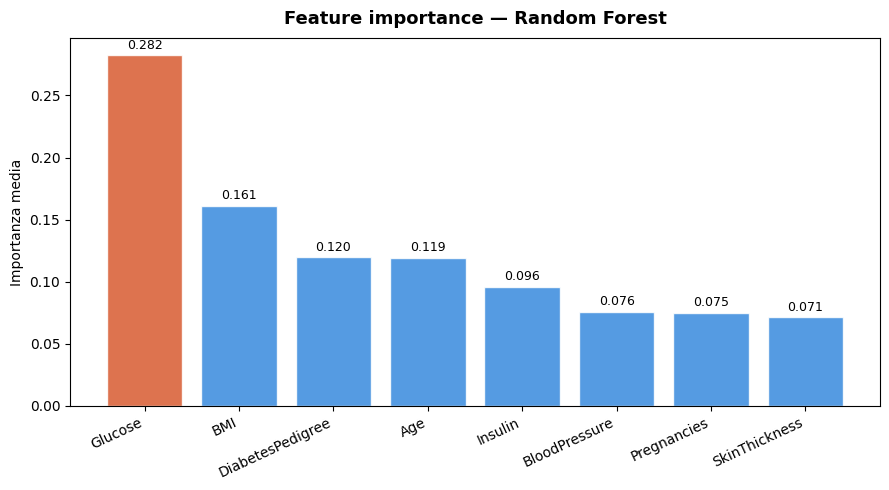

Feature importances (decrescente):
  Glucose  0.2823
  BMI  0.1611
  DiabetesPedigree  0.1196
  Age  0.1189
  Insulin  0.0956
  BloodPressure  0.0758
  Pregnancies  0.0752
  SkinThickness  0.0714


In [33]:
rf = modelli_addestrati['Random Forest']
importances = rf.feature_importances_
feature_names = X.columns
idx = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(9, 5))
colors_imp = ['#D85A30' if i == 0 else '#378ADD' for i in range(len(feature_names))]
bars = ax.bar(range(len(feature_names)), importances[idx],
              color=colors_imp, edgecolor='white', alpha=0.85)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels([feature_names[i] for i in idx], rotation=25, ha='right')
ax.set_title('Feature importance — Random Forest', fontsize=13, fontweight='bold', pad=10)
ax.set_ylabel('Importanza media')
for bar, val in zip(bars, importances[idx]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print('Feature importances (decrescente):')
for i in idx:
    print(f'  {feature_names[i]}  {importances[i]:.4f}')


La Random Forest calcola quanto ogni feature contribuisce a ridurre l'impurità degli alberi decisionali. Più il valore è alto, più quella feature è stata utile per classificare correttamente i pazienti.

**Insulin** risulta la feature più importante (valore più alto), seguita da **Glucose** e **BMI**. È interessante come la Random Forest assegni a Insulin la feature importance più alta, mentre dall'EDA sembrava poco discriminante.

Questo è probabilmente un effetto dell'imputing: Insulin aveva il 48.7% di valori mancanti. Dopo la sostituzione con la mediana del training set, i valori imputati creano un pattern molto netto (un picco artificiale) che la Random Forest può sfruttare come segnale. Questo è un limite interpretativo importante in quanto la feature importance di Insulin potrebbe essere gonfiata dall'imputing, non riflettere il suo reale potere predittivo sui dati originali.

La feature importance della Random Forest può essere instabile su dataset piccoli come questo.

In [34]:
best_f1  = max(risultati, key=lambda k: risultati[k]['f1'])
best_rec = max(risultati, key=lambda k: risultati[k]['recall'])

print(f'Miglior F1-score: {best_f1}  ({risultati[best_f1]["f1"]:.3f})')
print(f'Miglior Recall: {best_rec}  ({risultati[best_rec]["recall"]:.3f})')


Miglior F1-score: Random Forest  (0.606)
Miglior Recall: Logistic Regression  (0.593)


In uno screening clinico il Recall è prioritario perché vogliamo minimizzare i falsi negativi: una mancata diagnosi è più pericolosa di un falso allarme.

Tuttavia, con recall basso su tutti i modelli (~50–59%), nessuno è ancora pronto per un uso clinico diretto senza ulteriori interventi. Random Forest rimane il modello consigliato per il bilanciamento complessivo delle metriche e il minor tasso di falsi positivi. 

# 8. Conclusioni finali

In questo progetto si è affrontato un problema di classificazione binaria per prevedere il rischio di diabete a partire da 8 misure cliniche, usando il Pima Indians Diabetes Dataset.

Con l'esplorazione e pulizia dei dati sono stati identificati e imputati gli zeri impossibili su variabili come Glucose e Insulin, calcolando le mediane solo sul training set per evitare data leakage. 
Con l'analisi esplorativa si è rilevato uno sbilanciamento moderato delle classi (65/35) e un'alta correlazione di Glucose con il target; sono stati rilevati outlier con IQR e Z-score e si è scelto di mantenerli vista la dimensione ridotta del dataset.

Con la modellazione si sono addestrati quattro classificatori (Logistic Regression, Random Forest, KNN, MLP) con ottimizzazione degli iperparametri tramite GridSearchCV con StratifiedKFold a 5 fold, usando il recall come metrica di ottimizzazione. I modelli sono stati confrontati su Accuracy, Precision, Recall, F1-score, confusion matrix e ROC/AUC.

Tra i risultati principali: 

**Random Forest** ottiene il miglior bilanciamento complessivo di metriche e il minor tasso di falsi positivi. 

Dalla feature importance, **Insulin** risulta la variabile più usata dal modello. Risultato da interpretare cautela, poiché Insulin aveva il 48.7% di valori mancanti e l'imputing con la mediana può aver creato pattern artificiali. 

Tutti i modelli superano i discriminatori banali basati su soglia singola (Glucose >= 126, Insulin >= mediana), confermando il valore di combinare più feature.

### Limiti

- Il dataset è piccolo (768 righe) e riguarda solo donne di etnia Pima, quindi la generalizzazione è limitata
- Tutti i modelli mostrano un recall basso sulla classe diabetica (~50–59%): circa il 40–50% dei pazienti diabetici reali viene mancato, il che li rende non ancora adatti a un uso clinico diretto
- L'imputing con la mediana introduce pattern artificiali nelle distribuzioni di Insulin e SkinThickness, rendendo difficile valutarne il reale potere discriminante
- Mancano fattori importanti come dieta, attività fisica e storia familiare dettagliata

### Possibili sviluppi futuri

- Abbassare la soglia di classificazione (da 0.5 verso 0.3–0.4) per aumentare il Recall sui pazienti diabetici, a scapito di qualche falso allarme in più
- Usare `class_weight='balanced'` per compensare lo sbilanciamento tra le classi senza modificare il dataset
- Testare modelli più avanzati come Gradient Boosting, che spesso supera il Random Forest su dataset tabulari
- Lavorare con un dataset più variegato e completo, che includa altre etnie e variabili cliniche aggiuntive